<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/PCA_serieal_ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/cereal.csv'
df = pd.read_csv(url)

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB
None


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


- mlr: 시리얼 제조업체
- type: 저온용 또는 고온용
- calories : 1회분에 대한 칼로리
- protein : 단백질(g)
- fat : 지방(g)
- sodium : 나트륨(mg)
- fiber : 식이섬유(g)
- carbo : 복합 탄수화물(g)
- sugars : 설탕(g)
- potass : 칼륨(g)
- vitamins : 비타민과 미네랄:FDA의 권장비율로서 0, 25 또는 100을 나타냄
- shell :디스플레이 선반
- weight : 1회분의 무게(Ounces)
- rating : 소비자 보고서에 의한 시리얼 평점

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (20.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and direc

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

Step 1: 데이터 불러오기 및 전처리
--------------------------------------------------
데이터셋 크기: (77, 16)
컬럼 목록: ['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups', 'rating']

데이터 첫 5행:
                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100% Bran   N    C        70        4    1     130   10.0   
1          100% Natural Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4             Almond Delight   R    C       110        2    2     200    1.0   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  
0    5.0       6     280        25      3     1.0  0.33  68.402973  
1    8.0       8     135         0      3     1.0  1.00  33.983679  
2    7.0       5     320        25      3     1.0  

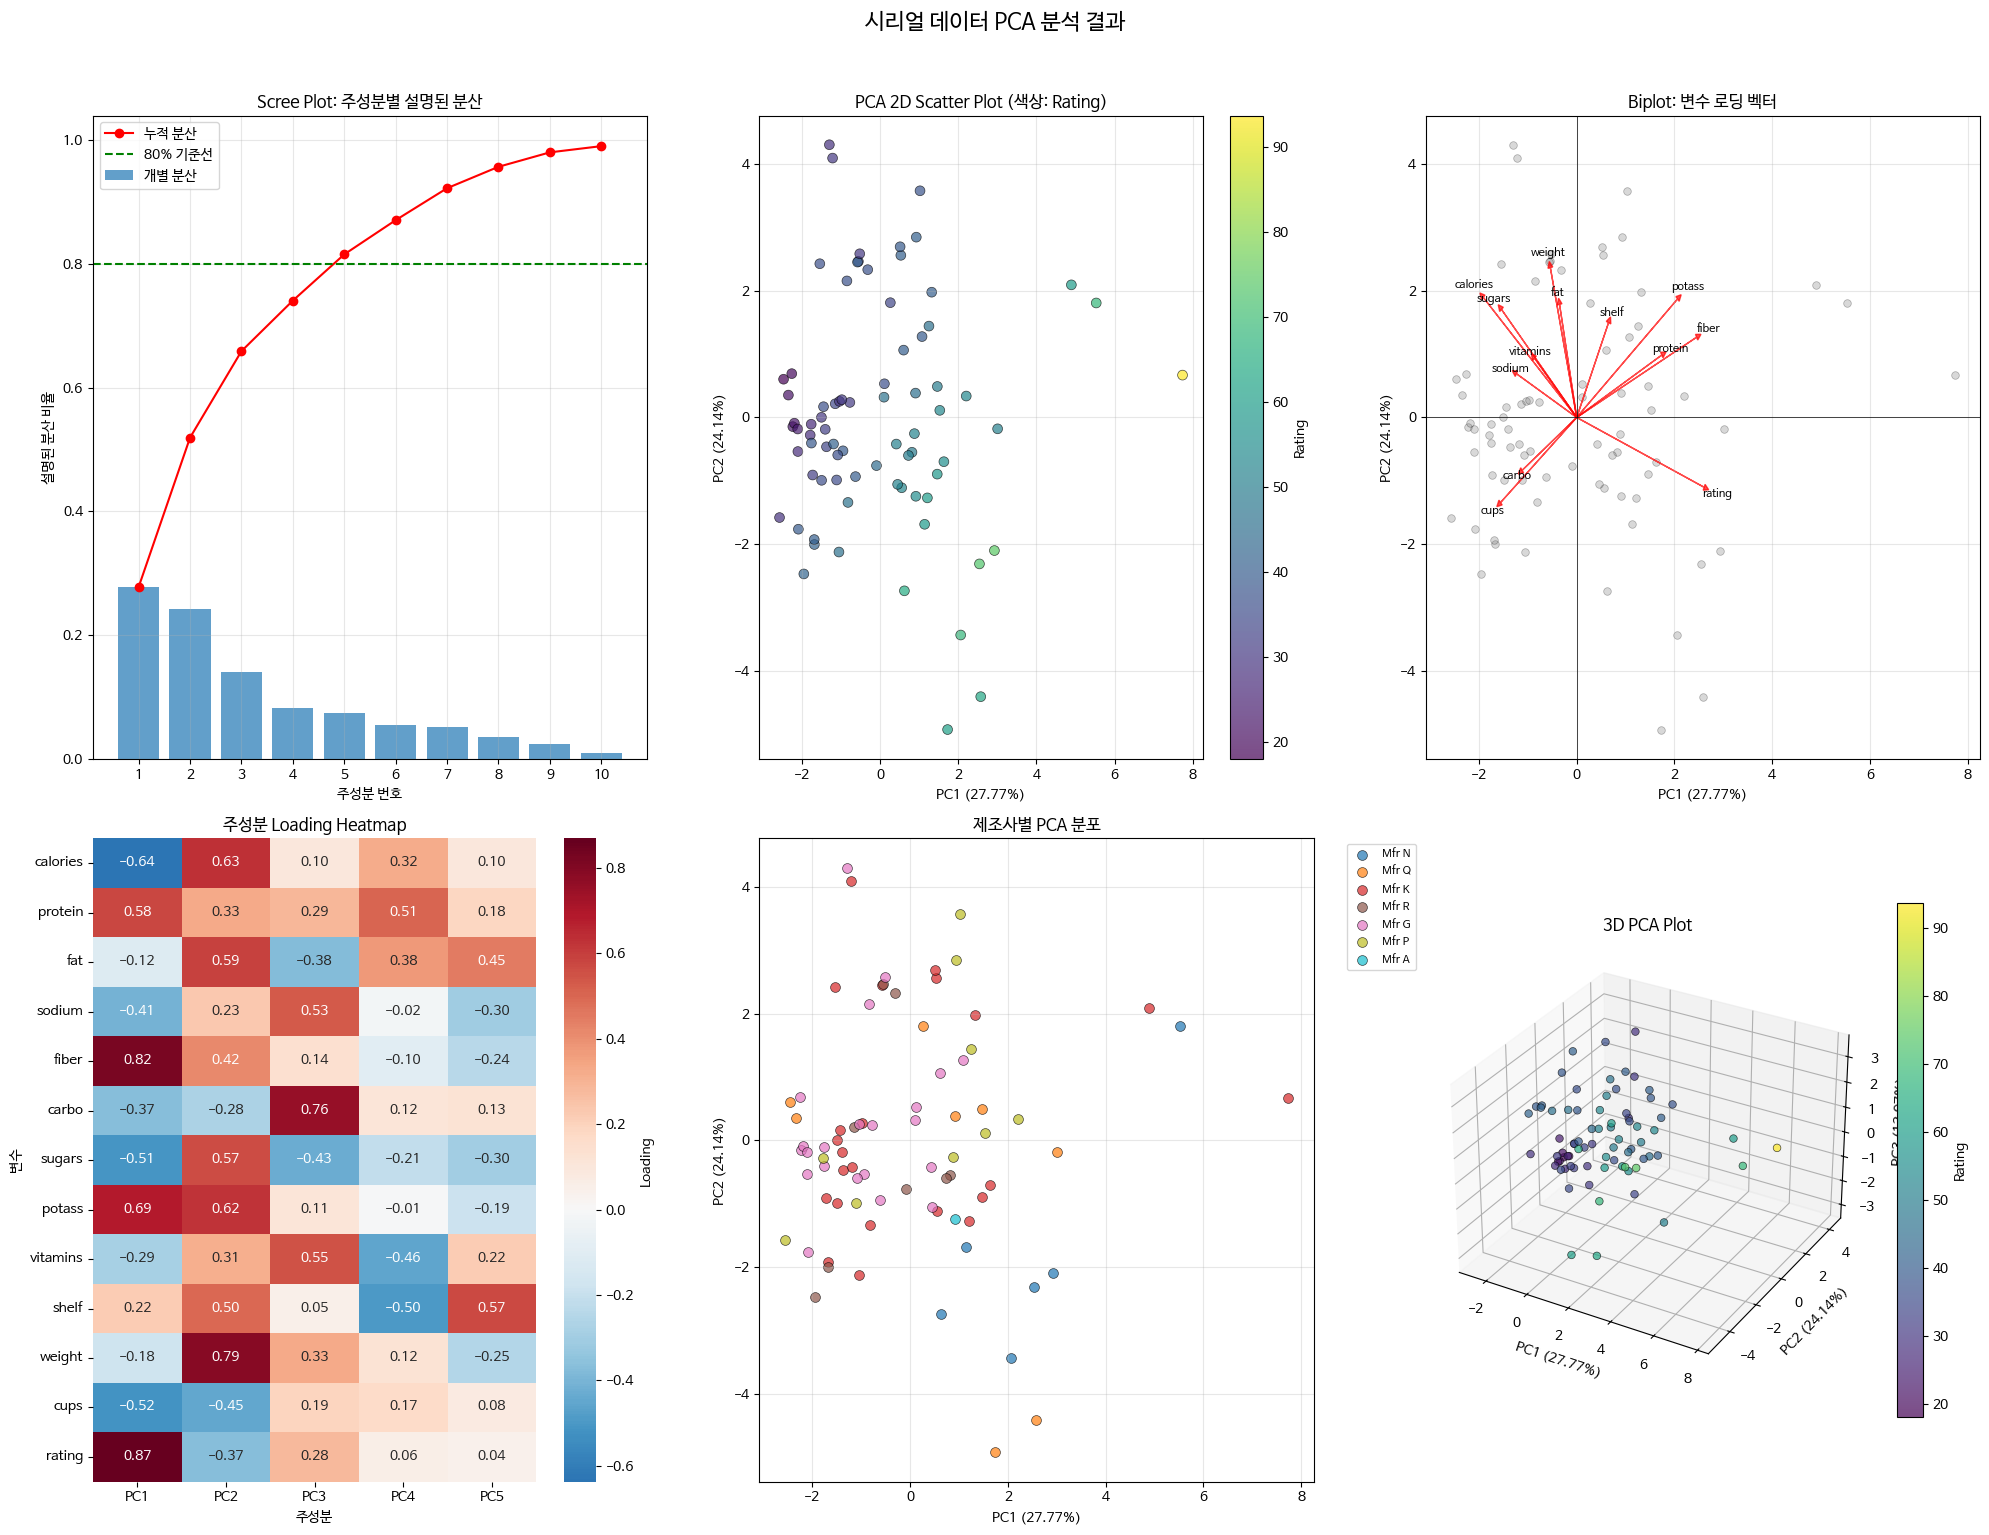


Step 7: PCA 점수 기반 추가 분석
--------------------------------------------------

PC1 점수 상위 5개 시리얼 (영양 특성):
                         name       PC1     rating
3   All-Bran with Extra Fiber  7.737473  93.704912
0                   100% Bran  5.529765  68.402973
2                    All-Bran  4.893527  59.425505
57             Quaker Oatmeal  3.007328  50.828392
64     Shredded Wheat 'n'Bran  2.925075  74.472949

PC1 점수 하위 5개 시리얼:
                     name       PC1     rating
37             Honey-comb -2.571399  28.742414
10           Cap'n'Crunch -2.468141  18.042851
35       Honey Graham Ohs -2.344991  21.871292
12  Cinnamon Toast Crunch -2.258249  19.823573
14            Cocoa Puffs -2.231541  22.736446

주성분과 Rating의 상관관계:
PC1 vs Rating: r = 0.864, p-value = 0.0000
PC2 vs Rating: r = -0.365, p-value = 0.0011

PCA 분석 완료!


In [ ]:
"""
시리얼 데이터셋에 대한 주성분 분석(PCA) 및 시각화
"""

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 한글 폰트 설정 (Colab 환경에 설치된 'NanumBarunGothic' 사용)
# 폰트 설치 후 런타임 다시 시작 및 폰트 설정 셀 실행 필요
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# =============================================================================
# Step 1: 데이터 불러오기 및 전처리
# =============================================================================
print("Step 1: 데이터 불러오기 및 전처리")
print("-" * 50)

# 데이터 불러오기
#df = pd.read_csv('cereal.csv') # 이미 로드된 df 사용

# 데이터 기본 정보 확인
print(f"데이터셋 크기: {df.shape}")
print(f"컬럼 목록: {df.columns.tolist()}")
print("\n데이터 첫 5행:")
print(df.head())

# 첫 3개 컬럼(name, mfr, type) 제외하고 숫자형 변수만 선택
numeric_columns = df.columns[3:].tolist()
print(f"\nPCA에 사용할 변수들: {numeric_columns}")

# PCA용 데이터 준비
X = df[numeric_columns].copy()

# 결측치 확인 및 처리
print(f"\n결측치 개수:\n{X.isnull().sum()}")
if X.isnull().sum().sum() > 0:
    # 결측치가 있다면 평균값으로 대체
    X = X.fillna(X.mean())
    print("결측치를 평균값으로 대체했습니다.")

# =============================================================================
# Step 2: 데이터 표준화
# =============================================================================
print("\n" + "="*50)
print("Step 2: 데이터 표준화")
print("-" * 50)

# StandardScaler를 사용한 표준화 (평균 0, 표준편차 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 표준화된 데이터를 DataFrame으로 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_columns)
print("표준화 완료")
print(f"표준화 후 평균: {X_scaled_df.mean().round(6).tolist()[:3]}... (처음 3개만 표시)")
print(f"표준화 후 표준편차: {X_scaled_df.std().round(6).tolist()[:3]}... (처음 3개만 표시)")

# =============================================================================
# Step 3: PCA 수행
# =============================================================================
print("\n" + "="*50)
print("Step 3: PCA 수행")
print("-" * 50)

# 모든 주성분을 계산
pca_full = PCA()
pca_full.fit(X_scaled)

# 설명된 분산 비율
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"주성분 개수: {len(explained_variance_ratio)}")
print("\n각 주성분의 설명된 분산 비율:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance_ratio)):
    print(f"PC{i+1}: {var:.4f} (누적: {cum_var:.4f})")
    if cum_var >= 0.95:  # 95% 이상 설명되면 중단
        print(f"\n=> 처음 {i+1}개의 주성분이 전체 분산의 {cum_var:.2%}를 설명합니다.")
        break

# =============================================================================
# Step 4: 최적 주성분 개수 선택 및 변환
# =============================================================================
print("\n" + "="*50)
print("Step 4: 최적 주성분 개수 선택")
print("-" * 50)

# 누적 분산이 80% 이상인 최소 주성분 개수 찾기
n_components_80 = np.argmax(cumulative_variance_ratio >= 0.80) + 1
print(f"80% 분산 설명에 필요한 주성분 개수: {n_components_80}")

# 2개 주성분으로 PCA 수행 (시각화용)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"\n2개 주성분의 설명된 분산 비율:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"총 설명된 분산: {sum(pca_2d.explained_variance_ratio_):.4f}")

# =============================================================================
# Step 5: 주성분 해석 - Loading 분석
# =============================================================================
print("\n" + "="*50)
print("Step 5: 주성분 해석 - Loading 분석")
print("-" * 50)

# Loading matrix (주성분과 원래 변수들의 상관관계)
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)
loading_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=numeric_columns
)

print("\nLoading Matrix (주성분과 변수들의 관계):")
print(loading_df.round(3))

# 각 주성분에서 가장 중요한 변수들
print("\nPC1에서 가장 중요한 변수 Top 5:")
pc1_importance = loading_df['PC1'].abs().sort_values(ascending=False)
print(pc1_importance.head().round(3))

print("\nPC2에서 가장 중요한 변수 Top 5:")
pc2_importance = loading_df['PC2'].abs().sort_values(ascending=False)
print(pc2_importance.head().round(3))

# =============================================================================
# Step 6: 시각화
# =============================================================================
print("\n" + "="*50)
print("Step 6: 시각화")
print("-" * 50)

# 전체 시각화를 위한 figure 생성
fig = plt.figure(figsize=(20, 15))

# 1. Scree Plot (설명된 분산)
ax1 = plt.subplot(2, 3, 1)
n_components_to_plot = min(10, len(explained_variance_ratio))
x_pos = np.arange(1, n_components_to_plot + 1)
ax1.bar(x_pos, explained_variance_ratio[:n_components_to_plot], alpha=0.7, label='개별 분산')
ax1.plot(x_pos, cumulative_variance_ratio[:n_components_to_plot], 'ro-', label='누적 분산')
ax1.axhline(y=0.8, color='g', linestyle='--', label='80% 기준선')
ax1.set_xlabel('주성분 번호')
ax1.set_ylabel('설명된 분산 비율')
ax1.set_title('Scree Plot: 주성분별 설명된 분산')
ax1.set_xticks(x_pos)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. PCA 2D Scatter Plot
ax2 = plt.subplot(2, 3, 2)
scatter = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=df['rating'], cmap='viridis',
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
ax2.set_title('PCA 2D Scatter Plot (색상: Rating)')
plt.colorbar(scatter, ax=ax2, label='Rating')
ax2.grid(True, alpha=0.3)

# 3. Biplot (변수 로딩 벡터)
ax3 = plt.subplot(2, 3, 3)
# 데이터 포인트
ax3.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
            alpha=0.3, s=30, color='gray', edgecolors='black', linewidth=0.5)
# 로딩 벡터
scale_factor = 3  # 화살표 크기 조정
for i, var in enumerate(numeric_columns):
    ax3.arrow(0, 0,
              loadings[i, 0] * scale_factor,
              loadings[i, 1] * scale_factor,
              head_width=0.1, head_length=0.1,
              fc='red', ec='red', alpha=0.7)
    ax3.text(loadings[i, 0] * scale_factor * 1.1,
             loadings[i, 1] * scale_factor * 1.1,
             var, fontsize=8, ha='center', va='center')
ax3.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
ax3.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
ax3.set_title('Biplot: 변수 로딩 벡터')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# 4. Loading Heatmap
ax4 = plt.subplot(2, 3, 4)
# 더 많은 주성분을 포함한 loading matrix
pca_5d = PCA(n_components=min(5, X_scaled.shape[1]))
pca_5d.fit(X_scaled)
loadings_5d = pca_5d.components_.T * np.sqrt(pca_5d.explained_variance_)
loading_df_5d = pd.DataFrame(
    loadings_5d,
    columns=[f'PC{i+1}' for i in range(pca_5d.n_components_)],
    index=numeric_columns
)
sns.heatmap(loading_df_5d, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Loading'}, ax=ax4)
ax4.set_title('주성분 Loading Heatmap')
ax4.set_ylabel('변수')
ax4.set_xlabel('주성분')

# 5. 제조사별 PCA 분포
ax5 = plt.subplot(2, 3, 5)
manufacturers = df['mfr'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(manufacturers)))
for i, mfr in enumerate(manufacturers):
    mask = df['mfr'] == mfr
    ax5.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Mfr {mfr}', color=colors[i],
                s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
ax5.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
ax5.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
ax5.set_title('제조사별 PCA 분포')
ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. 3D PCA Plot (3개 주성분)
if X_scaled.shape[1] >= 3:
    ax6 = fig.add_subplot(2, 3, 6, projection='3d')
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    scatter_3d = ax6.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                             c=df['rating'], cmap='viridis',
                             s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax6.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
    ax6.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
    ax6.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
    ax6.set_title('3D PCA Plot')
    plt.colorbar(scatter_3d, ax=ax6, label='Rating', shrink=0.8)

plt.suptitle('시리얼 데이터 PCA 분석 결과', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# Step 7: PCA 점수를 사용한 추가 분석
# =============================================================================
print("\n" + "="*50)
print("Step 7: PCA 점수 기반 추가 분석")
print("-" * 50)

# PCA 점수를 데이터프레임에 추가
df_with_pca = df.copy()
df_with_pca['PC1'] = X_pca_2d[:, 0]
df_with_pca['PC2'] = X_pca_2d[:, 1]

# PC1 상위/하위 시리얼
print("\nPC1 점수 상위 5개 시리얼 (영양 특성):")
top_pc1 = df_with_pca.nlargest(5, 'PC1')[['name', 'PC1', 'rating']]
print(top_pc1.to_string())

print("\nPC1 점수 하위 5개 시리얼:")
bottom_pc1 = df_with_pca.nsmallest(5, 'PC1')[['name', 'PC1', 'rating']]
print(bottom_pc1.to_string())

# Rating과 주성분의 상관관계
from scipy import stats
corr_pc1_rating = stats.pearsonr(df_with_pca['PC1'], df_with_pca['rating'])
corr_pc2_rating = stats.pearsonr(df_with_pca['PC2'], df_with_pca['rating'])

print(f"\n주성분과 Rating의 상관관계:")
print(f"PC1 vs Rating: r = {corr_pc1_rating[0]:.3f}, p-value = {corr_pc1_rating[1]:.4f}")
print(f"PC2 vs Rating: r = {corr_pc2_rating[0]:.3f}, p-value = {corr_pc2_rating[1]:.4f}")

print("\n" + "="*50)
print("PCA 분석 완료!")
print("="*50)